## <centered> CATARACT EYE VS NORMAL EYE DETECTION 👁️👁️

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 
from tensorflow.keras.utils import to_categorical, plot_model
import os

import warnings
warnings.filterwarnings("ignore")

### Cataract and Normal image dataset preprocessing

### Cataract Eye:

In [ ]:
data = []
result = []

#👁️ Cataract eye
for r, d, f in os.walk("D:\eye\Cataract\Test\Cataract"):
    for file in f:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(r, file)

            img = Image.open(path)
            img = img.resize((128, 128))
            img = np.array(img) / 255.0  

            if img.shape == (128, 128, 3):
                data.append(img)
                result.append([0, 1])  

### Normal Eye:

In [3]:
for r, d, f in os.walk("D:\\eye\\Cataract\\Test\\Normal"):
    for file in f:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(r, file)

            img = Image.open(path)
            img = img.resize((128, 128))
            img = np.array(img) / 255.0

            if img.shape == (128, 128, 3):
                data.append(img)
                result.append([1, 0])

In [4]:
data = np.array(data)
result = np.array(result)

print("Data shape:", data.shape)      
print("Result shape:", result.shape)

Data shape: (1600, 128, 128, 3)
Result shape: (1600, 2)


### Visualization

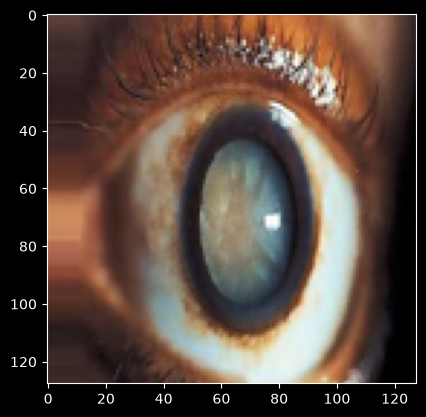

In [5]:
plt.imshow(data[240])

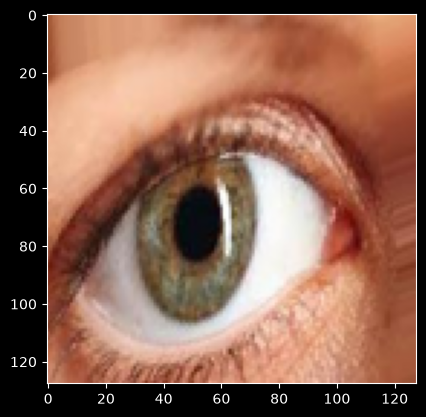

In [6]:
plt.imshow(data[1120])

### Data Splitting

In [7]:
x_train, x_test, y_train, y_test = train_test_split(data, result, test_size=0.2, shuffle=True, random_state=42)

### Model creation using Sequential Method(CNN MODEL)
    

In [8]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3), padding='same'))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2, activation='softmax'))

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,621,922 (128.26 MB)

 Trainable params: 33,621,730 (128.26 MB)

 Non-trainable params: 192 (768.00 B)

None


### Model Configuration

In [9]:
model.compile(loss="binary_crossentropy",optimizer='adam',metrics=['accuracy'])

In [10]:
x_train.shape

(1280, 128, 128, 3)

In [11]:
y_train.shape

(1280, 2)

### Model Training

In [15]:
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    verbose=1,
    validation_data=(x_test, y_test))

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.9969 - loss: 0.0115 - val_accuracy: 0.5531 - val_loss: 11.9857
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.9961 - loss: 0.0119 - val_accuracy: 0.6000 - val_loss: 9.0654
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.9953 - loss: 0.0146 - val_accuracy: 0.5719 - val_loss: 11.2720
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.9937 - loss: 0.0244 - val_accuracy: 0.6125 - val_loss: 10.3778
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 86s 4s/step - accuracy: 0.9969 - loss: 0.0119 - val_accuracy: 0.6687 - val_loss: 6.3868
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.9984 - loss: 0.0061 - val_accuracy: 0.6438 - val_loss: 8.5994
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 85s 4s/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 0.6750 - val_loss: 6.8764
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - accuracy: 0.9992 - loss: 0.0042 - val_accuracy: 0.6844 - val_lo

### Model Evaluation

In [16]:
score = model.evaluate(x_test, y_test, batch_size=64)
print("\nTest accuracy: %.1f%%" % (100.0 * score[1]))

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 605ms/step - accuracy: 0.7094 - loss: 4.9709

Test accuracy: 70.9%


### PREDICTION

In [ ]:
from PIL import Image

img_path = r"D:\eye\Cataract\Test\Cataract\cat_0_49.jpg"
img = Image.open(img_path)
img = img.resize((128,128))
img = np.array(img) / 255.0   # 🔥 same preprocessing

img = np.expand_dims(img, axis=0)  

prediction = model.predict(img)
pred_class = np.argmax(prediction)

if pred_class == 0:
    print("Prediction: Cataract eye")
else:
    print("Prediction:  Normal eye")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Prediction: Cataract eye
